In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [20]:
data = pd.read_csv("IMDB_Movies_Data.csv")

print(data.head())
print(data.info())
print(data.describe())

        id                                    title release_date  \
0  1127164                  Beetlejuice Beetlejuice   2024-09-04   
1   493529  Dungeons & Dragons: Honor Among Thieves   2023-03-23   
2   177677       Mission: Impossible - Rogue Nation   2015-07-28   
3  1064028                             Subservience   2024-08-15   
4  1405338                               Demon City   2025-02-26   

                            genres     budget    revenue  runtime  \
0            Comedy,Fantasy,Horror  100000000  451900435      105   
1         Adventure,Fantasy,Comedy  151000000  208200000      134   
2                 Action,Adventure  150000000  682716636      131   
3  Science Fiction,Horror,Thriller    4400000     262793      105   
4    Action,Crime,Fantasy,Thriller          0          0      106   

   vote_average  vote_count  popularity original_language  \
0         6.999        2681     10.3224                en   
1         7.300        4097      9.2202               

In [21]:
data = data.dropna()
data = data.drop(['id', 'title', 'overview'], axis=1, errors='ignore')
categorical_cols = ['genres', 'original_language', 
                    'production_countries', 'production_companies', 
                    'cast', 'director']

In [22]:
for col in categorical_cols:
    if col in data.columns:
        data[col] = data[col].astype('category').cat.codes

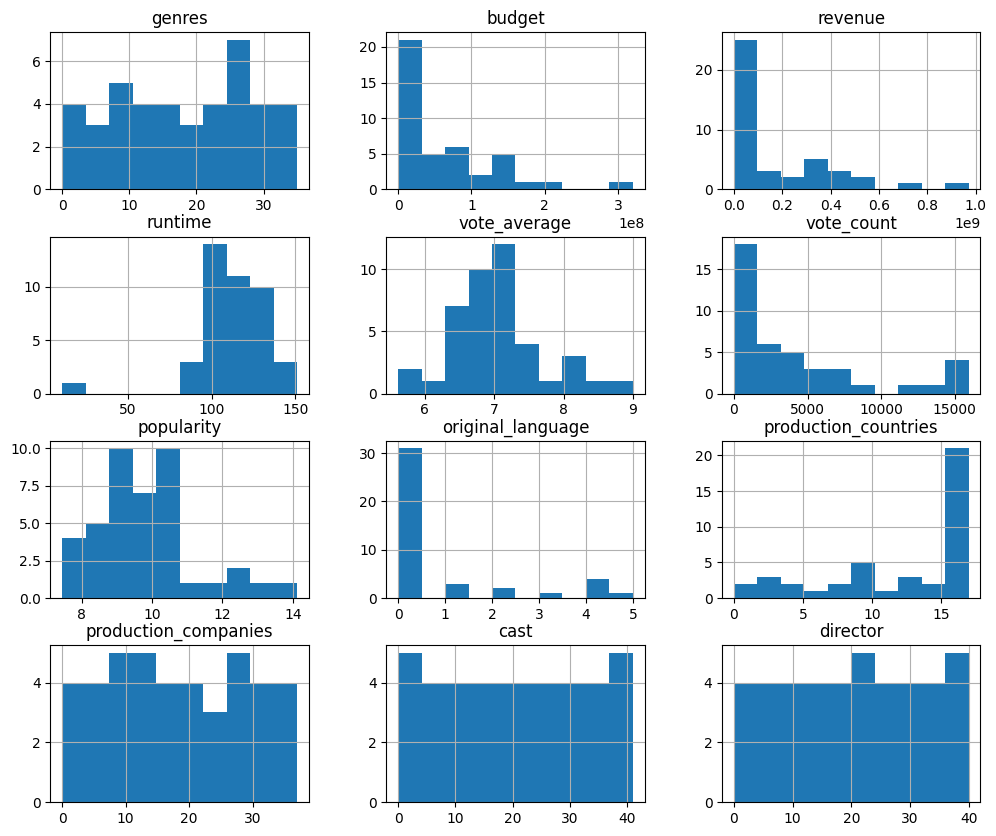

In [23]:
data.hist(figsize=(12,10))
plt.show()

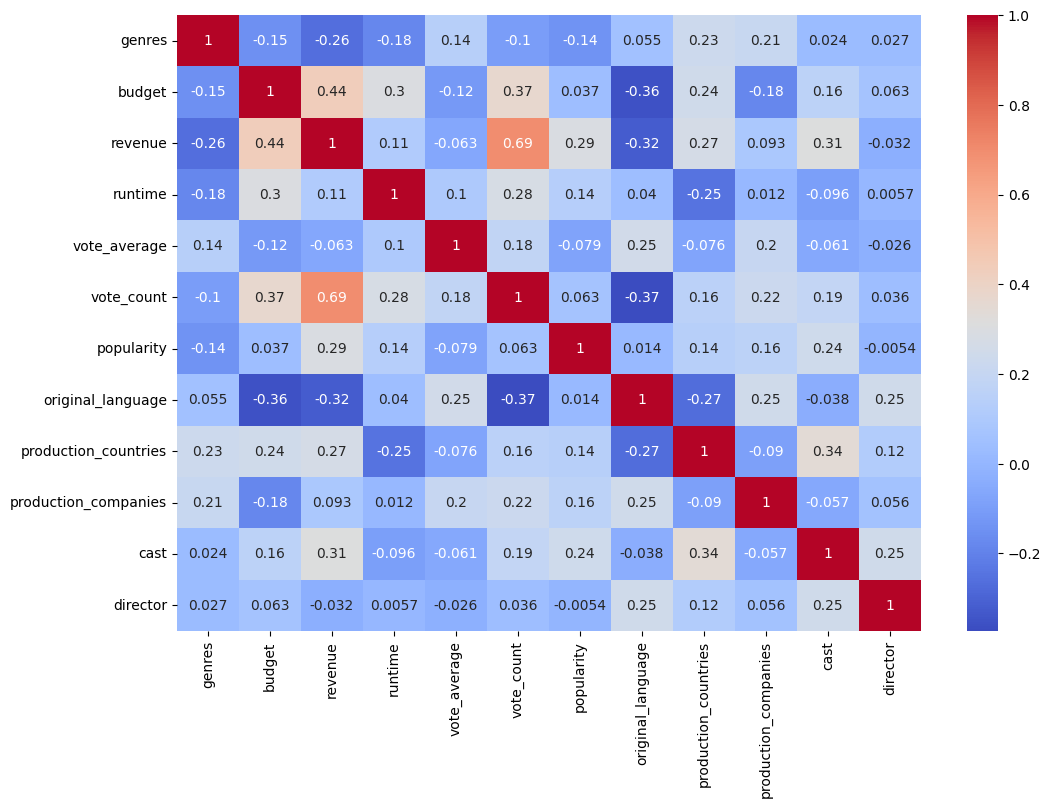

In [24]:
plt.figure(figsize=(12,8))
numeric_data = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.show()

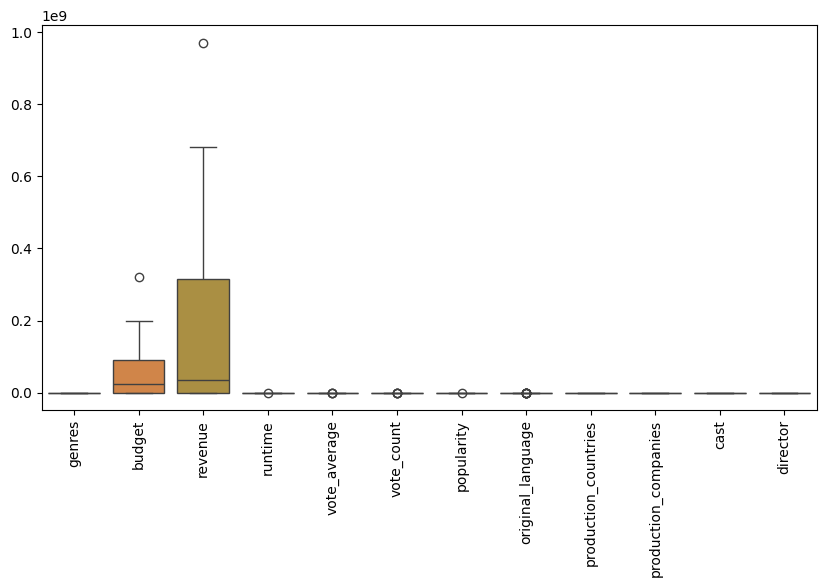

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

In [26]:
numeric_data = data.select_dtypes(include=[np.number])

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

filtered_data = numeric_data[~((numeric_data < (Q1 - 1.5 * IQR)) | 
                               (numeric_data > (Q3 + 1.5 * IQR))).any(axis=1)]

data = data.loc[filtered_data.index]

In [32]:
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')
data['release_year'] = data['release_date'].dt.year
data = data.drop('release_date', axis=1)

In [33]:
data = data.select_dtypes(include=[np.number])

In [34]:
X = data.drop('revenue', axis=1)
y = data['revenue']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [39]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)


Model Evaluation:
Mean Squared Error (MSE): 0.8
R2 Score: -2.333333333333333


In [41]:
threshold = data["revenue"].median()
y_class = (y > threshold).astype(int) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.2
